**Owner: Dennis**

## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### (Optional) Run this notebook in Google Colab
If your laptop can't run the CNN, **download this notebook**, open it in Colab, then upload `realwaste.zip` into Colab's **Files** panel (left sidebar). Run the cell below once, then run the rest of the notebook normally. On VS Code with a GPU, **skip this cell**.

In [1]:
# --- Optional Colab bootstrap: run ONLY on Google Colab ---
import sys, os, zipfile, pathlib, shutil, subprocess
if "google.colab" in sys.modules:
    subprocess.run(["pip","-q","install","tensorflow","scikit-learn","seaborn"], check=False)
    # after uploading realwaste.zip to the Files panel, unzip it to ./RealWaste (matches the pipeline cell)
    if not pathlib.Path("RealWaste").exists() and pathlib.Path("realwaste.zip").exists():
        with zipfile.ZipFile("realwaste.zip") as z: z.extractall("_tmp")
        for p in pathlib.Path("_tmp").rglob("RealWaste"):
            shutil.move(str(p), "RealWaste"); break
        shutil.rmtree("_tmp", ignore_errors=True)
    print("Colab ready. RealWaste present:", os.path.isdir("RealWaste"))

### 2.1 Preprocess Images

In [1]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

import os
import pathlib
import tensorflow as tf

# ---------------------------------------------------------
# Dataset location
# ---------------------------------------------------------
# In Google Colab, the master's bootstrap extracts the dataset into ./RealWaste.

# When running locally from the sections folder, the dataset is one level above in ../data/RealWaste.
# ---------------------------------------------------------

if os.path.isdir("RealWaste"):

    data_dir = pathlib.Path("RealWaste")

else:

    data_dir = pathlib.Path("../data/RealWaste")


print("Dataset path:", data_dir)
print("Dataset exists:", data_dir.is_dir())


# ---------------------------------------------------------
# CNN image settings
# ---------------------------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42


# ---------------------------------------------------------
# Load training dataset
# ---------------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)


# ---------------------------------------------------------
# Load validation dataset
# ---------------------------------------------------------

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)


# ---------------------------------------------------------
# Dataset information
# ---------------------------------------------------------

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Class names:", class_names)

Dataset path: ..\data\RealWaste
Dataset exists: True
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


In [2]:
# ---------------------------------------------------------
# Split the validation holdout into validation and test sets
# ---------------------------------------------------------
# The original pipeline uses half of the 950-image holdout for validation and half for testing.

# ---------------------------------------------------------

validation_batches = tf.data.experimental.cardinality(
    validation_ds
).numpy()

test_batches = validation_batches // 2

test_dataset = validation_ds.take(test_batches)
validation_ds = validation_ds.skip(test_batches)

print("Number of training batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Number of validation batches:",
      tf.data.experimental.cardinality(validation_ds).numpy())

print("Number of test batches:",
      tf.data.experimental.cardinality(test_dataset).numpy())

Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


In [3]:
# ---------------------------------------------------------
# Verify one batch from the training dataset
# ---------------------------------------------------------

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 9)
Minimum pixel value: 0.0
Maximum pixel value: 255.0


In [4]:
# ---------------------------------------------------------
# MobileNetV2 preprocessing
# ---------------------------------------------------------
# MobileNetV2 expects image values to be scaled to the range [-1, 1].
#
# This performs the normalization required before the images are passed into the pretrained MobileNetV2 model.
# ---------------------------------------------------------

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input


def preprocess_images(images, labels):
    images = preprocess_input(images)
    return images, labels


# Apply MobileNetV2 preprocessing to each dataset.
train_ds_preprocessed = train_ds.map(
    preprocess_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds_preprocessed = validation_ds.map(
    preprocess_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset_preprocessed = test_dataset.map(
    preprocess_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [5]:
# ---------------------------------------------------------
# Verify MobileNetV2 preprocessing
# ---------------------------------------------------------

images, labels = next(iter(train_ds_preprocessed))

print("Preprocessed image batch shape:", images.shape)
print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())

Preprocessed image batch shape: (32, 224, 224, 3)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


### 2.2 Implement CNN Model with Transfer Learning

In [ ]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# ---------------------------------------------------------
# MobileNetV2 Transfer Learning Model
# ---------------------------------------------------------
# MobileNetV2 is used as the pretrained feature extractor.
# The ImageNet classification head is removed because our task has 9 waste categories.
# ---------------------------------------------------------

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained feature extractor for the baseline.
base_model.trainable = False


# ---------------------------------------------------------
# Add the custom classification head
# ---------------------------------------------------------

model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    # Dropout provides regularization and helps reduce overfitting in the classification head.
    tf.keras.layers.Dropout(
        0.3,
        name="classification_dropout"
    ),

    # Nine output classes corresponding to RealWaste.
    tf.keras.layers.Dense(
        9,
        activation="softmax",
        name="predictions"
    )
])


# ---------------------------------------------------------
# Display model information
# ---------------------------------------------------------

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout          │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
# ---------------------------------------------------------
# Compile the baseline CNN model
# ---------------------------------------------------------
# Adam is used as the optimizer with a learning rate of 1e-3.
# Categorical crossentropy is appropriate because the labels are one-hot encoded across the 9 waste categories.
# ---------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [14]:
# ---------------------------------------------------------
# Training callbacks
# ---------------------------------------------------------
# EarlyStopping prevents unnecessary training when the validation loss stops improving.
#
# ReduceLROnPlateau lowers the learning rate when validation loss stops improving, allowing the model to make smaller updates and potentially improve further.
# ---------------------------------------------------------

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

### 2.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# ---------------------------------------------------------
# Train the baseline MobileNetV2 model
# ---------------------------------------------------------
# The pretrained MobileNetV2 feature extractor is frozen, so this first training stage only learns the new classification head.


history = model.fit(
    train_ds_preprocessed,
    validation_data=validation_ds_preprocessed,
    epochs=20,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 77s 570ms/step - accuracy: 0.5145 - loss: 1.3856 - val_accuracy: 0.7149 - val_loss: 0.7971 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 66s 549ms/step - accuracy: 0.7020 - loss: 0.8191 - val_accuracy: 0.7426 - val_loss: 0.6800 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 83s 554ms/step - accuracy: 0.7591 - loss: 0.6760 - val_accuracy: 0.7979 - val_loss: 0.6190 - learning_rate: 0.0010
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 548ms/step - accuracy: 0.7851 - loss: 0.6016 - val_accuracy: 0.8170 - val_loss: 0.5523 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 65s 541ms/step - accuracy: 0.8159 - loss: 0.5309 - val_accuracy: 0.7830 - val_loss: 0.5804 - learning_rate: 0.0010
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 65s 545ms/step - accuracy: 0.8259 - loss: 0.4929 - val_accuracy: 0.8043 - val_loss: 0.5674 - learning_rate: 0.0010
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 66s 550ms/step - accuracy: 0.8

In [20]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# ---------------------------------------------------------
# Cache the test dataset so evaluation and predictions use the same test images
# ---------------------------------------------------------

test_dataset_preprocessed = test_dataset_preprocessed.cache()
# ---------------------------------------------------------
# Evaluate the baseline model on the test set
# ---------------------------------------------------------

test_loss, test_accuracy = model.evaluate(
    test_dataset_preprocessed,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step - accuracy: 0.8083 - loss: 0.5531
Test Loss: 0.5531
Test Accuracy: 0.8083
Test Accuracy: 80.83%


In [21]:
# ---------------------------------------------------------
# Generate predictions for detailed evaluation
# ---------------------------------------------------------

import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset_preprocessed:
    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        tf.argmax(labels, axis=1).numpy()
    )

    y_pred.extend(
        tf.argmax(predictions, axis=1).numpy()
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test labels:", len(y_true))
print("Number of predictions:", len(y_pred))

Number of test labels: 480
Number of predictions: 480


In [22]:
# ---------------------------------------------------------
# Classification report
# ---------------------------------------------------------

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                     precision    recall  f1-score   support

          Cardboard       0.70      0.78      0.74        40
      Food Organics       0.84      0.95      0.89        40
              Glass       0.80      0.65      0.72        37
              Metal       0.87      0.81      0.84        91
Miscellaneous Trash       0.75      0.56      0.64        48
              Paper       0.82      0.89      0.85        63
            Plastic       0.73      0.85      0.78        85
      Textile Trash       0.84      0.84      0.84        44
         Vegetation       1.00      0.91      0.95        32

           accuracy                           0.81       480
          macro avg       0.82      0.80      0.81       480
       weighted avg       0.81      0.81      0.81       480



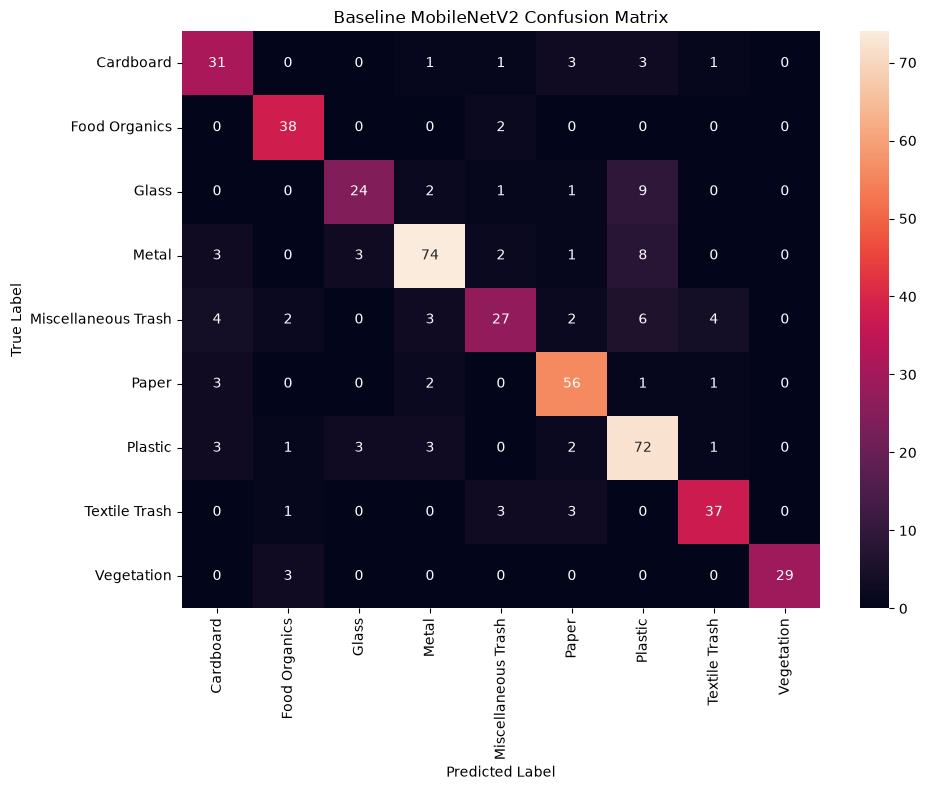

In [23]:
# ---------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.show()

### Baseline Model Error Analysis

The baseline MobileNetV2 transfer-learning model achieved a test accuracy of
80.83% on the 480-image test set.

The confusion matrix shows that the model performs particularly well on
Food Organics, Paper, Plastic, Textile Trash and Vegetation. Miscellaneous
Trash and Glass were more challenging categories, with recall values of
56% and 65% respectively.

The most frequent classification errors involved Glass being predicted as
Plastic, Metal being predicted as Plastic, and Miscellaneous Trash being
predicted as Plastic. Other errors included confusion between Cardboard and
Plastic, Plastic and Metal, and Paper and Cardboard.

These errors suggest that some waste categories share visual characteristics
that make them difficult to distinguish. Miscellaneous Trash is also a
challenging category because it contains a diverse range of waste items.

These error patterns provide a basis for the fine-tuning experiment in
Section 2.4.

### 2.4 Fine-tune the Model

In [25]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# ---------------------------------------------------------
# Fine-tune the MobileNetV2 model
# ---------------------------------------------------------
# The baseline model used a frozen MobileNetV2 feature extractor. In this stage, selected upper layers are unfrozen so that the pretrained features 
# can adapt to the RealWaste dataset.

# Earlier layers remain frozen because they capture more general visual features.

# Batch Normalization layers remain frozen to help maintain stable pretrained representations during fine-tuning.
# ---------------------------------------------------------

base_model.trainable = True

fine_tune_from = 124

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total base model layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_from)
print(
    "Trainable base model layers:",
    sum(
        1 for layer in base_model.layers
        if layer.trainable
    )
)

print(
    "Total trainable parameters:",
    sum(
        np.prod(layer.shape)
        for layer in model.trainable_weights
    )
)

Total base model layers: 154
Fine-tuning from layer: 124
Trainable base model layers: 19
Total trainable parameters: 1522249


In [26]:
# ---------------------------------------------------------
# Recompile with a smaller learning rate
# ---------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [27]:
# ---------------------------------------------------------
# Fine-tuning callbacks
# ---------------------------------------------------------

fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

In [28]:
# ---------------------------------------------------------
# Train the fine-tuned model
# ---------------------------------------------------------

fine_tune_history = model.fit(
    train_ds_preprocessed,
    validation_data=validation_ds_preprocessed,
    epochs=15,
    callbacks=[
        fine_tune_early_stopping,
        fine_tune_reduce_lr
    ],
    verbose=1
)

Epoch 1/15


c:\Users\ADMIN\anaconda3\envs\ml_lab\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


119/119 ━━━━━━━━━━━━━━━━━━━━ 50s 389ms/step - accuracy: 0.8448 - loss: 0.4258 - val_accuracy: 0.8106 - val_loss: 0.4883 - learning_rate: 1.0000e-05
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 49s 410ms/step - accuracy: 0.8724 - loss: 0.3668 - val_accuracy: 0.8213 - val_loss: 0.4842 - learning_rate: 1.0000e-05
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 49s 414ms/step - accuracy: 0.8930 - loss: 0.3139 - val_accuracy: 0.8468 - val_loss: 0.4622 - learning_rate: 1.0000e-05
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 50s 415ms/step - accuracy: 0.9001 - loss: 0.2902 - val_accuracy: 0.8426 - val_loss: 0.4866 - learning_rate: 1.0000e-05
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 80s 396ms/step - accuracy: 0.9248 - loss: 0.2405 - val_accuracy: 0.8553 - val_loss: 0.4691 - learning_rate: 1.0000e-05
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 49s 406ms/step - accuracy: 0.9345 - loss: 0.2089 - val_accuracy: 0.8553 - val_loss: 0.4695 - learning_rate: 2.0000e-06
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 49s 413ms/step - 

In [29]:
# ---------------------------------------------------------
# Evaluate the fine-tuned model on the test set
# ---------------------------------------------------------

fine_tune_test_loss, fine_tune_test_accuracy = model.evaluate(
    test_dataset_preprocessed,
    verbose=1
)

print(f"Fine-Tuned Test Loss: {fine_tune_test_loss:.4f}")
print(f"Fine-Tuned Test Accuracy: {fine_tune_test_accuracy:.4f}")
print(
    f"Fine-Tuned Test Accuracy: "
    f"{fine_tune_test_accuracy * 100:.2f}%"
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 270ms/step - accuracy: 0.8687 - loss: 0.4371
Fine-Tuned Test Loss: 0.4371
Fine-Tuned Test Accuracy: 0.8687
Fine-Tuned Test Accuracy: 86.87%


In [30]:
# ---------------------------------------------------------
# Fine-Tuned Model Classification Report
# ---------------------------------------------------------

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_dataset_preprocessed:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

print("Fine-Tuned Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=2
    )
)

Fine-Tuned Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.83      0.85      0.84        40
      Food Organics       0.90      0.93      0.91        40
              Glass       0.90      0.76      0.82        37
              Metal       0.94      0.88      0.91        91
Miscellaneous Trash       0.78      0.75      0.77        48
              Paper       0.85      0.90      0.88        63
            Plastic       0.78      0.89      0.84        85
      Textile Trash       0.93      0.89      0.91        44
         Vegetation       1.00      0.94      0.97        32

           accuracy                           0.87       480
          macro avg       0.88      0.86      0.87       480
       weighted avg       0.87      0.87      0.87       480



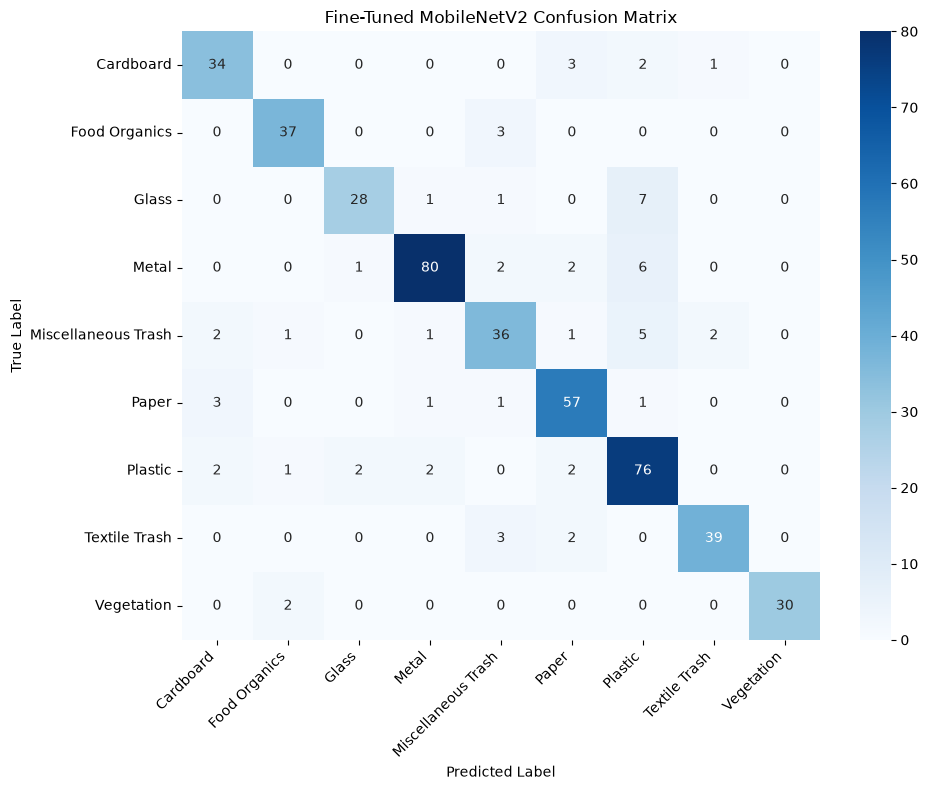

In [31]:
# ---------------------------------------------------------
# Fine-Tuned Model Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fine-Tuned MobileNetV2 Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Fine-Tuned Model Error Analysis

The fine-tuned MobileNetV2 model achieved a test accuracy of 86.87% on the 480-image test set, improving the baseline accuracy of 80.83% by 6.04
percentage points.

The classification results show improvements across all nine waste categories. The macro F1-score increased from 0.81 for the baseline model
to 0.87 after fine-tuning. The largest F1 improvements were observed for Miscellaneous Trash, Cardboard and Glass.

The confusion matrix shows that the most frequent remaining error is Glass being classified as Plastic, with 7 images misclassified. Metal was also
occasionally classified as Plastic with 6 errors, while 5 Miscellaneous Trash images were classified as Plastic.

Other smaller confusion patterns include Food Organics and Textile Trash being classified as Miscellaneous Trash, as well as confusion between
Cardboard and Paper.

Glass and Miscellaneous Trash remain the most challenging categories based on recall at 76% and 75%, respectively. In contrast, Vegetation achieved
94% recall and a 97% F1-score, while Food Organics achieved 93% recall and a 91% F1-score.

Overall, the confusion matrix indicates that fine-tuning improved the model's ability to distinguish several of the categories that were more
difficult for the baseline model. However, some visual similarities between waste categories, particularly those involving Plastic, Glass, Metal and
Miscellaneous Trash, remain a source of classification errors.

### Fine-Tuning Experiment Summary

The baseline MobileNetV2 model used ImageNet-pretrained weights with the convolutional base initially frozen and a custom classification head
containing Global Average Pooling, Dropout, and a 9-class softmax layer.

For the fine-tuning experiment, the upper portion of the MobileNetV2 base was unfrozen starting from layer 124, while earlier layers remained frozen.
Batch Normalization layers were kept frozen to improve training stability. The learning rate was reduced from 1e-3 during baseline training to 1e-5
during fine-tuning.

The fine-tuned model was trained for up to 15 epochs using EarlyStopping and ReduceLROnPlateau. The best validation accuracy reached 86.60% during training.

On the held-out 480-image test set, the baseline model achieved 80.83% accuracy, while the fine-tuned model achieved 86.87% accuracy. This
represents an improvement of 6.04 percentage points.

The results provide evidence that allowing the later MobileNetV2 layers to adapt to the RealWaste dataset improved classification performance compared
with using the frozen pretrained feature extractor alone.